```
Name : Min Thein Win
Admin No: 3907578Y
Date : 27 Feb 2025
```

# Project Overview

# **Title : Ticket Management System with AI-Powered Routing**
**Project Domain : Office Automation**

**Model : RoBERTa**


## Practice Code For Final Report

## A. Model Development
####Data Cleaning Process

In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Load the dataset
import pandas as pd
#df=pd.read_csv("/content/drive/My Drive/NYP-PDC2/Defect_ticket_v2.csv")#load file from google drive
df=pd.read_csv("Defect_ticket_v2.csv")

In [2]:
df.head(5)

,Ticket ID,Description,Comment,Summary,Category,Command,Environment,Model,Defect Creation Time,Tags,Assigned Team,Team Email
0,TID000001,Security token not refreshing correctly after ...,Reduce nested loops to enhance execution speed.,Logging Enhancements Suggested,Code Review,REVIEW CODE /MODULE_Z,Testing,Model_B,04 May 2024,Low,Code Review Team,codereview.team@company.com
1,TID000002,Code formatting inconsistencies violating styl...,Ensure consistent use of coding style guidelines.,Memory Leak Detected,Code Review,REVIEW CODE /MODULE_Z,Testing,Model_B,13 October 2024,High,Code Review Team,codereview.team@company.com
2,TID000003,Deprecated function usage causing compatibilit...,Test cases need to cover all edge scenarios.,Legacy Code Modernization Required,Code Review,REVIEW CODE /MODULE_Z,Testing,Model_B,02 October 2024,High,Code Review Team,codereview.team@company.com
3,TID000004,Code review revealed redundant function calls.,Code should follow DRY principles for modularity.,Concurrency Issues Identified,Code Review,REVIEW CODE /MODULE_Z,Testing,Model_B,12 February 2024,High,Code Review Team,codereview.team@company.com
4,TID000005,Logging system not capturing sufficient debug ...,Reduce nested loops to enhance execution speed.,Database Optimization Needed,Code Review,REVIEW CODE /MODULE_Z,Testing,Model_B,01 May 2024,Low,Code Review Team,codereview.team@company.com


In [3]:
df.dtypes

,0
Ticket ID,object
Description,object
Comment,object
Summary,object
Category,object
Command,object
Environment,object
Model,object
Defect Creation Time,object
Tags,object


In [4]:
### Handling NULL/Duplication Values
df.isnull().sum(axis = 0)

,0
Ticket ID,0
Description,0
Comment,0
Summary,0
Category,0
Command,0
Environment,0
Model,0
Defect Creation Time,0
Tags,0


In [5]:
# Count total Null in a DataFrame
print("Count total Null in a DataFrame : \n",
       df.isnull().sum().sum())

Count total Null in a DataFrame : 
 0


In [6]:
#Drop NaN values in every row,
df = df.dropna()

In [7]:
# Print the total rows after remove the Null.
print("Count total rows after remove the Null : \n",
       df.count())

Count total rows after remove the Null : 
 Ticket ID               5000
Description             5000
Comment                 5000
Summary                 5000
Category                5000
Command                 5000
Environment             5000
Model                   5000
Defect Creation Time    5000
Tags                    5000
Assigned Team           5000
Team Email              5000
dtype: int64


In [8]:
df.shape

(5000, 12)

In [9]:
# Print total number of rows before remove duplications
df.duplicated().value_counts()

,count
False,5000


In [10]:
# generate a table of those culprit rows which are duplicated:
df = df.groupby(df.columns.tolist()).size().reset_index().rename(columns={0:'duplicated'})
df.head()

,Ticket ID,Description,Comment,Summary,Category,Command,Environment,Model,Defect Creation Time,Tags,Assigned Team,Team Email,duplicated
0,TID000001,Security token not refreshing correctly after ...,Reduce nested loops to enhance execution speed.,Logging Enhancements Suggested,Code Review,REVIEW CODE /MODULE_Z,Testing,Model_B,04 May 2024,Low,Code Review Team,codereview.team@company.com,1
1,TID000002,Code formatting inconsistencies violating styl...,Ensure consistent use of coding style guidelines.,Memory Leak Detected,Code Review,REVIEW CODE /MODULE_Z,Testing,Model_B,13 October 2024,High,Code Review Team,codereview.team@company.com,1
2,TID000003,Deprecated function usage causing compatibilit...,Test cases need to cover all edge scenarios.,Legacy Code Modernization Required,Code Review,REVIEW CODE /MODULE_Z,Testing,Model_B,02 October 2024,High,Code Review Team,codereview.team@company.com,1
3,TID000004,Code review revealed redundant function calls.,Code should follow DRY principles for modularity.,Concurrency Issues Identified,Code Review,REVIEW CODE /MODULE_Z,Testing,Model_B,12 February 2024,High,Code Review Team,codereview.team@company.com,1
4,TID000005,Logging system not capturing sufficient debug ...,Reduce nested loops to enhance execution speed.,Database Optimization Needed,Code Review,REVIEW CODE /MODULE_Z,Testing,Model_B,01 May 2024,Low,Code Review Team,codereview.team@company.com,1


In [11]:
#Remove the duplications rows in the dataset
df_remove_dupliate = df.drop_duplicates()

In [12]:
#Print the total rows after remove the Null.
df.drop_duplicates(keep='first').count()

,0
Ticket ID,5000
Description,5000
Comment,5000
Summary,5000
Category,5000
Command,5000
Environment,5000
Model,5000
Defect Creation Time,5000
Tags,5000


In [13]:
# duplicate list, current dataset 0 mean no duplicate
print(df.count() - df.drop_duplicates(keep='first').count())

Ticket ID               0
Description             0
Comment                 0
Summary                 0
Category                0
Command                 0
Environment             0
Model                   0
Defect Creation Time    0
Tags                    0
Assigned Team           0
Team Email              0
duplicated              0
dtype: int64


In [14]:
#Print total number of rows after remove duplications
df.count()

,0
Ticket ID,5000
Description,5000
Comment,5000
Summary,5000
Category,5000
Command,5000
Environment,5000
Model,5000
Defect Creation Time,5000
Tags,5000


In [15]:
# Print total number of rows after remove duplications
df.duplicated().value_counts()

,count
False,5000


#### Feature Engineering

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Ticket ID               5000 non-null   object        
 1   Description             5000 non-null   object        
 2   Comment                 5000 non-null   object        
 3   Summary                 5000 non-null   object        
 4   Category                5000 non-null   object        
 5   Command                 5000 non-null   object        
 6   Defect Creation Time    5000 non-null   datetime64[ns]
 7   Tags                    5000 non-null   int64         
 8   Assigned Team           5000 non-null   object        
 9   Team Email              5000 non-null   object        
 10  duplicated              5000 non-null   int64         
 11  combined_text_feature   5000 non-null   object        
 12  creation_hour           5000 non-null   int32   

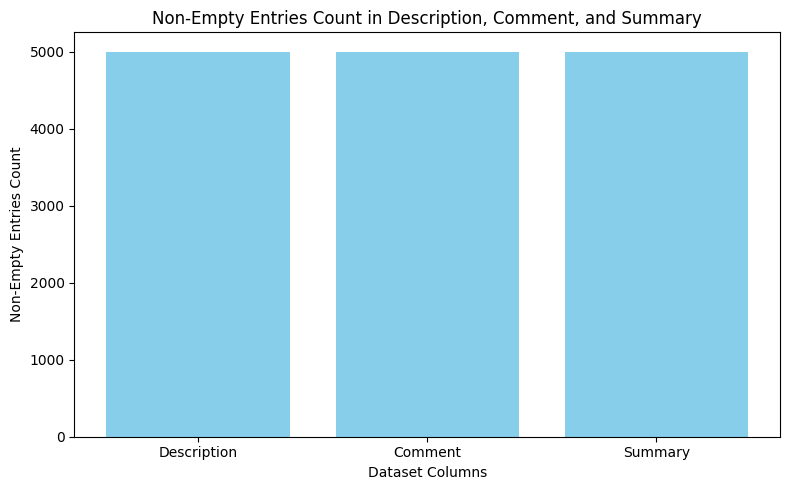

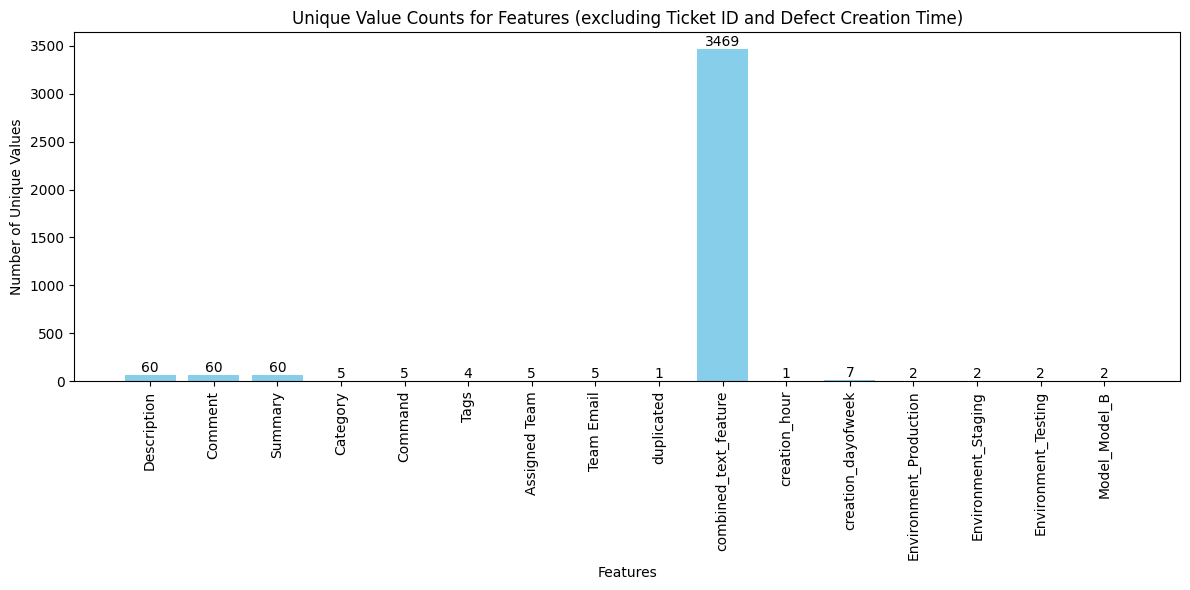

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# Data Cleaning & Feature Engineering
# --------------------------

# Fill missing values for text columns
text_columns = ['Description', 'Comment', 'Summary']
df[text_columns] = df[text_columns].fillna('')

# Combine Description, Summary, and Comment into a single text input using the special token separator “[SEP]”.
separator = " [SEP] "
df['combined_text_feature'] = df['Description'] + separator + df['Comment'] + separator + df['Summary']

# Convert 'Defect Creation Time' to datetime and extract time features
df['Defect Creation Time'] = pd.to_datetime(df['Defect Creation Time'], errors='coerce')
df['creation_hour'] = df['Defect Creation Time'].dt.hour
df['creation_dayofweek'] = df['Defect Creation Time'].dt.dayofweek

# One-hot encode categorical columns
categorical_cols = ['Environment', 'Model']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Map severity levels to numerical values for 'Tags'
severity_mapping = {'High': 3, 'Critical': 4, 'Medium': 2, 'Low': 1}
df['Tags'] = df['Tags'].map(severity_mapping).fillna(0).astype(int)

# Display basic DataFrame information
print(df.info())
print(df.head())

# --------------------------
# Exploratory Data Analysis (EDA)
# --------------------------

# Count non-empty entries in each text column using vectorized operations
text_counts = {col: df[col].str.strip().astype(bool).sum() for col in text_columns}

# Plot non-empty text counts
plt.figure(figsize=(8, 5))
plt.bar(text_counts.keys(), text_counts.values(), color='skyblue')
plt.xlabel("Dataset Columns")
plt.ylabel("Non-Empty Entries Count")
plt.title("Non-Empty Entries Count in Description, Comment, and Summary")
plt.tight_layout()
plt.show()

# Count unique values for each feature (excluding Ticket ID and Defect Creation Time)
exclude_columns = ['Ticket ID', 'Defect Creation Time']
features_to_count = [col for col in df.columns if col not in exclude_columns]
feature_counts = {col: df[col].nunique() for col in features_to_count}

# Plot unique value counts for each feature
plt.figure(figsize=(12, 6))
bars = plt.bar(feature_counts.keys(), feature_counts.values(), color='skyblue')
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Number of Unique Values")
plt.title("Unique Value Counts for Features (excluding Ticket ID and Defect Creation Time)")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), va='bottom', ha='center')
plt.tight_layout()
plt.show()


In [17]:
# Drop the specified columns from the DataFrame.
# Features selection
df = df.drop(columns=['Defect Creation Time', 'Tags','duplicated'])

In [18]:
df.columns

Index(['Ticket ID', 'Description', 'Comment', 'Summary', 'Category', 'Command',
       'Assigned Team', 'Team Email', 'combined_text_feature', 'creation_hour',
       'creation_dayofweek', 'Environment_Production', 'Environment_Staging',
       'Environment_Testing', 'Model_Model_B'],
      dtype='object')

In [19]:
df

,Ticket ID,Description,Comment,Summary,Category,Command,Assigned Team,Team Email,combined_text_feature,creation_hour,creation_dayofweek,Environment_Production,Environment_Staging,Environment_Testing,Model_Model_B
0,TID000001,Security token not refreshing correctly after ...,Reduce nested loops to enhance execution speed.,Logging Enhancements Suggested,Code Review,REVIEW CODE /MODULE_Z,Code Review Team,codereview.team@company.com,Security token not refreshing correctly after ...,0,5,False,False,True,True
1,TID000002,Code formatting inconsistencies violating styl...,Ensure consistent use of coding style guidelines.,Memory Leak Detected,Code Review,REVIEW CODE /MODULE_Z,Code Review Team,codereview.team@company.com,Code formatting inconsistencies violating styl...,0,6,False,False,True,True
2,TID000003,Deprecated function usage causing compatibilit...,Test cases need to cover all edge scenarios.,Legacy Code Modernization Required,Code Review,REVIEW CODE /MODULE_Z,Code Review Team,codereview.team@company.com,Deprecated function usage causing compatibilit...,0,2,False,False,True,True
3,TID000004,Code review revealed redundant function calls.,Code should follow DRY principles for modularity.,Concurrency Issues Identified,Code Review,REVIEW CODE /MODULE_Z,Code Review Team,codereview.team@company.com,Code review revealed redundant function calls....,0,0,False,False,True,True
4,TID000005,Logging system not capturing sufficient debug ...,Reduce nested loops to enhance execution speed.,Database Optimization Needed,Code Review,REVIEW CODE /MODULE_Z,Code Review Team,codereview.team@company.com,Logging system not capturing sufficient debug ...,0,2,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,TID004996,Unauthorized access detected in restricted sec...,Upgrade security patches to prevent exploitation.,Authentication bypass vulnerability discovered.,Security Vulnerability,VALIDATE SECURITY PATCH,Security Team,security.team@company.com,Unauthorized access detected in restricted sec...,0,4,False,True,False,False
4996,TID004997,Injection attack possible due to improper inpu...,Enforce stricter role-based access controls.,"User privileges incorrectly assigned, leading ...",Security Vulnerability,VALIDATE SECURITY PATCH,Security Team,security.team@company.com,Injection attack possible due to improper inpu...,0,1,False,True,False,False
4997,TID004998,"Security patch deployment failed, exposing kno...",Implement logging for better security auditing.,Injection attacks possible due to input flaws.,Security Vulnerability,VALIDATE SECURITY PATCH,Security Team,security.team@company.com,"Security patch deployment failed, exposing kno...",0,0,False,True,False,False
4998,TID004999,Injection attack possible due to improper inpu...,Enhance session security with proper expiratio...,Unpatched vulnerabilities expose system threats.,Security Vulnerability,VALIDATE SECURITY PATCH,Security Team,security.team@company.com,Injection attack possible due to improper inpu...,0,2,False,True,False,False


First load the data and prepare it for the Roberta model.

In [20]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# Ensure 'Assigned Team' is categorical
df['Assigned Team'] = df['Assigned Team'].astype('category')
df['label'] = df['Assigned Team'].cat.codes

# Ensure only one "Team Email" column exists
if 'Team Email' not in df.columns:
    raise ValueError("The dataset does not contain a 'Team Email' column!")

# Create mappings from label to assigned team and team email
label_to_team = dict(enumerate(df['Assigned Team'].cat.categories))
team_to_email = dict(zip(df['Assigned Team'], df['Team Email']))

# Load tokenizer and model for RoBERTa
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
num_labels = len(df['Assigned Team'].unique())
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=num_labels)

# Split the data into training and validation sets
# Ensure missing values are handled
df['Description'] = df['Description'].fillna("")
df['Comment'] = df['Comment'].fillna("")
df['Summary'] = df['Summary'].fillna("")

# Combine Description, Summary, and Comment into a single text input using the special token separator “[SEP]”.
separator = " [SEP] "
df['combined_colum_feature'] = df['Description'] + separator + df['Comment'] + separator + df['Summary']

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['combined_colum_feature'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




*   Tokenization of Input Texts.
*   Custom Dataset Class for Ticket Classification and Creating.
*   Datasets and DataLoaders.

Assigned Team and Corresponding Email Mappings

In [21]:
# Display processed dataset mappings for reference
team_email_mappings = pd.DataFrame(list(team_to_email.items()), columns=['Assigned Team', 'Team Email'])

# Alternative to ace_tools: Print the dataframe in a formatted way
print("=== Assigned Team and Corresponding Email Mappings ===")
print(team_email_mappings.to_string(index=False))  # Print nicely formatted output

=== Assigned Team and Corresponding Email Mappings ===
      Assigned Team                   Team Email
   Code Review Team  codereview.team@company.com
    Functional Team  functional.team@company.com
   Performance Team performance.team@company.com
Infrastructure Team       infra.team@company.com
      Security Team    security.team@company.com


#### Model Selection
Model selection and training. We'll use the RoBERTaForSequenceClassification model from Hugging Face, which is designed for classification tasks.



In [ ]:
!pip install transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 24.1 MB/s eta 0:00:00


In [22]:
import torch
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast  # Mixed precision training
from transformers import get_scheduler
from tqdm import tqdm
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import wandb


#### Model Pre-Training
We'll load a pre-trained RoBERTa model and fine-tune it on our ticket dataset. We'll use a classification head with the number of classes equal to the number of unique teams in the dataset.

In [23]:
# Tokenize input texts with max_length 256
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=256)

# Define custom dataset class for ticket classification.
class TicketDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

# Create dataset and dataloaders
train_dataset = TicketDataset(train_encodings, train_labels)
val_dataset = TicketDataset(val_encodings, val_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# Load pre-trained RoBERTa model with a classification head
num_labels = len(df['Assigned Team'].unique())
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=num_labels)

# Set device to GPU if available, otherwise CPU
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Define optimizer with weight decay
optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)

# Define loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Set up linear learning rate scheduler with warmup
epochs = 5
num_training_steps = len(train_loader) * epochs
num_warmup_steps = int(0.1 * num_training_steps)  # Warmup for 10% of training steps
lr_scheduler = get_scheduler("linear", optimizer=optimizer,
                             num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps)

# Initialize mixed precision training scaler
scaler = GradScaler()

# ----------------------------
# Initialize Wandb
wandb.init(project="Pretrain-Multitask-roBERTa", config={
    "epochs": epochs,
    "learning_rate": 3e-5,
    "batch_size": 16,
    "max_length": 256,
    "num_labels": num_labels
})
wandb.watch(model, log="all")
# ----------------------------

# Training loop with Wandb logging
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for batch in progress_bar:
        batch = {key: val.to(device) for key, val in batch.items()}

        with autocast():  # Enable mixed precision
            outputs = model(**batch)
            logits = outputs.logits
            loss = loss_fn(logits, batch["labels"])

        # Compute accuracy for the batch
        predictions = torch.argmax(logits, dim=-1)
        correct += (predictions == batch["labels"]).sum().item()
        total += batch["labels"].size(0)

        optimizer.zero_grad()
        scaler.scale(loss).backward()  # AMP scaling
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total

    # Log training metrics for the current epoch to Wandb
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "train_accuracy": accuracy,
        "learning_rate": lr_scheduler.get_last_lr()[0]
    })

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

# Finish Wandb run
wandb.finish()


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-23-054e2badbb52>:48: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mmtw-cs (mmtw-cs-nanyang-polytechnic) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


...

Epoch 4/5: 100%|██████████| 250/250 [00:23<00:00, 10.84it/s, loss=0.00109]


Epoch 4/5, Loss: 0.0013, Accuracy: 1.0000


Epoch 5/5: 100%|██████████| 250/250 [00:21<00:00, 11.65it/s, loss=0.00121]

Epoch 5/5, Loss: 0.0011, Accuracy: 1.0000


epoch,▁▃▅▆█
learning_rate,█▆▅▃▁
train_accuracy,▁████
train_loss,█▁▁▁▁
epoch,5
learning_rate,0
train_accuracy,1
train_loss,0.00114


#### Classification Report

In [24]:
from sklearn.metrics import classification_report

# Function to get predictions
def get_predictions(model, dataloader):
    model.eval()
    predictions, true_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            batch = {key: val.to(device) for key, val in batch.items()}
            outputs = model(**batch)
            _, preds = torch.max(outputs.logits, 1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(batch['labels'].cpu().numpy())
    return predictions, true_labels

# Get predictions for the validation set
val_predictions, val_true_labels = get_predictions(model, val_loader)

# Generate a classification report using Assigned Team names
report = classification_report(val_true_labels, val_predictions, target_names=df['Assigned Team'].cat.categories)
print("=== Classification Report ===")
print(report)

=== Classification Report ===
                     precision    recall  f1-score   support

   Code Review Team       1.00      1.00      1.00       216
    Functional Team       1.00      1.00      1.00       190
Infrastructure Team       1.00      1.00      1.00       210
   Performance Team       1.00      1.00      1.00       192
      Security Team       1.00      1.00      1.00       192

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



In [25]:
# Convert numeric labels back to team names
predicted_teams = [label_to_team[label] for label in val_predictions]
true_teams = [label_to_team[label] for label in val_true_labels]

# Get corresponding team emails
predicted_emails = [team_to_email[team] for team in predicted_teams]
true_emails = [team_to_email[team] for team in true_teams]

# Create a DataFrame for detailed comparison
comparison_df = pd.DataFrame({
    'True Team': true_teams,
    'True Email': true_emails,
    'Predicted Team': predicted_teams,
    'Predicted Email': predicted_emails
})

# Display the comparison results
print("\n=== Prediction vs Actual ===")
print(comparison_df.to_string(index=False))  # Nicely formatted output

# Optionally, save to a CSV for further analysis
comparison_df.to_csv("predictions_vs_actual.csv", index=False)
print("\nSaved to predictions_vs_actual.csv")


=== Prediction vs Actual ===
          True Team                   True Email      Predicted Team              Predicted Email
    Functional Team  functional.team@company.com     Functional Team  functional.team@company.com
   Performance Team performance.team@company.com    Performance Team performance.team@company.com
   Performance Team performance.team@company.com    Performance Team performance.team@company.com
    Functional Team  functional.team@company.com     Functional Team  functional.team@company.com
   Code Review Team  codereview.team@company.com    Code Review Team  codereview.team@company.com
   Code Review Team  codereview.team@company.com    Code Review Team  codereview.team@company.com
   Code Review Team  codereview.team@company.com    Code Review Team  codereview.team@company.com
   Performance Team performance.team@company.com    Performance Team performance.team@company.com
   Performance Team performance.team@company.com    Performance Team performance.team@co

#### Evaluation
##### Hyperparameter tuning and training

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import RobertaModel, RobertaTokenizer, get_linear_schedule_with_warmup
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
import wandb
import pandas as pd


# Set device: GPU if available, otherwise CPU
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Load tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Prepare labels: converting to categorical types and then codes
df['Assigned Team'] = df['Assigned Team'].astype('category')
df['Team Email'] = df['Team Email'].astype('category')
df['team_label'] = df['Assigned Team'].cat.codes
df['email_label'] = df['Team Email'].cat.codes

# Create mappings for reference (if needed)
label_to_team = dict(enumerate(df['Assigned Team'].cat.categories))
label_to_email = dict(enumerate(df['Team Email'].cat.categories))

# Fill missing values and combine text columns
df['Description'] = df['Description'].fillna('')
df['Comment'] = df['Comment'].fillna('')
df['Summary'] = df['Summary'].fillna('')

# Combine Description, Summary, and Comment into a single text input using the special token separator “[SEP]”.
separator = " [SEP] "
df['combined_colum_feature'] = df['Description'] + separator + df['Comment'] + separator + df['Summary']

# Split dataset into training and validation sets
train_texts, val_texts, train_teams, val_teams, train_emails, val_emails = train_test_split(
    df['combined_colum_feature'].tolist(),
    df['team_label'].tolist(),
    df['email_label'].tolist(),
    test_size=0.2,
    random_state=42
)

# Tokenize inputs
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=512)

# Define custom dataset
class MultiLabelDataset(Dataset):
    def __init__(self, encodings, team_labels, email_labels):
        self.encodings = encodings
        self.team_labels = team_labels
        self.email_labels = email_labels

    def __len__(self):
        return len(self.team_labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['team_labels'] = torch.tensor(self.team_labels[idx])
        item['email_labels'] = torch.tensor(self.email_labels[idx])
        return item

# Create datasets and dataloaders
train_dataset = MultiLabelDataset(train_encodings, train_teams, train_emails)
val_dataset = MultiLabelDataset(val_encodings, val_teams, val_emails)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32)

# Define the multi-task model with dropout regularization in classification heads
# andDefine the Custom Fine-Tuned RoBERTa Model
class MultiTaskRoberta(nn.Module):
    def __init__(self, num_teams, num_emails, dropout_prob=0.1):
        super(MultiTaskRoberta, self).__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        self.dropout = nn.Dropout(dropout_prob)
        self.team_classifier = nn.Linear(self.roberta.config.hidden_size, num_teams)
        self.email_classifier = nn.Linear(self.roberta.config.hidden_size, num_emails)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # CLS token output
        cls_output = self.dropout(cls_output)
        team_logits = self.team_classifier(cls_output)
        email_logits = self.email_classifier(cls_output)
        return team_logits, email_logits

num_teams = len(df['Assigned Team'].unique())
num_emails = len(df['Team Email'].unique())
model = MultiTaskRoberta(num_teams, num_emails, dropout_prob=0.1).to(device)

# Define optimizer with a lower learning rate and weight decay
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
team_criterion = nn.CrossEntropyLoss()
email_criterion = nn.CrossEntropyLoss()

# Set up scheduler with warmup
num_epochs = 5
total_steps = len(train_dataloader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)

scaler = GradScaler()

# Early stopping parameters
best_val_loss = float('inf')
patience = 2
patience_counter = 0
gradient_accumulation_steps = 2

# ----------------------------
# Initialize Wandb
wandb.init(project="Evaluation-Multitask-roBERTa", config={
    "epochs": num_epochs,
    "learning_rate": 2e-5,
    "batch_size": 32,
    "gradient_accumulation_steps": gradient_accumulation_steps,
    "dropout_prob": 0.1
})
wandb.watch(model, log="all", log_freq=10)
# ----------------------------

# Define evaluation function
def evaluate_model(model, dataloader):
    model.eval()
    total_loss = 0
    correct_teams = 0
    correct_emails = 0
    total_samples = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            team_labels = batch['team_labels'].to(device)
            email_labels = batch['email_labels'].to(device)
            team_logits, email_logits = model(input_ids=input_ids, attention_mask=attention_mask)
            team_loss = team_criterion(team_logits, team_labels)
            email_loss = email_criterion(email_logits, email_labels)
            loss = team_loss + email_loss
            total_loss += loss.item()
            team_preds = team_logits.argmax(dim=-1)
            email_preds = email_logits.argmax(dim=-1)
            correct_teams += (team_preds == team_labels).sum().item()
            correct_emails += (email_preds == email_labels).sum().item()
            total_samples += team_labels.size(0)
    avg_loss = total_loss / len(dataloader)
    team_accuracy = 100 * correct_teams / total_samples
    email_accuracy = 100 * correct_emails / total_samples
    return avg_loss, team_accuracy, email_accuracy

# Training loop with Wandb logging
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for step, batch in enumerate(train_dataloader):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        team_labels = batch['team_labels'].to(device)
        email_labels = batch['email_labels'].to(device)

        with autocast():
            team_logits, email_logits = model(input_ids=input_ids, attention_mask=attention_mask)
            team_loss = team_criterion(team_logits, team_labels)
            email_loss = email_criterion(email_logits, email_labels)
            loss = (team_loss + email_loss) / gradient_accumulation_steps

        scaler.scale(loss).backward()
        if (step + 1) % gradient_accumulation_steps == 0 or (step + 1) == len(train_dataloader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_dataloader)

    # Evaluate on validation set
    val_loss, team_acc, email_acc = evaluate_model(model, val_dataloader)
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, "
          f"Team Acc: {team_acc:.2f}%, Email Acc: {email_acc:.2f}%")

    # Log metrics to Wandb
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": val_loss,
        "team_accuracy": team_acc,
        "email_accuracy": email_acc,
        "learning_rate": scheduler.get_last_lr()[0]
    })

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

print("Training complete!")
wandb.finish()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-27-8dd960451f18>:102: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


<ipython-input-27-8dd960451f18>:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1: Train Loss: 1.3639, Val Loss: 0.3132, Team Acc: 98.80%, Email Acc: 98.90%
Epoch 2: Train Loss: 0.0392, Val Loss: 0.0037, Team Acc: 100.00%, Email Acc: 100.00%
Epoch 3: Train Loss: 0.0021, Val Loss: 0.0016, Team Acc: 100.00%, Email Acc: 100.00%
Epoch 4: Train Loss: 0.0014, Val Loss: 0.0012, Team Acc: 100.00%, Email Acc: 100.00%
Epoch 5: Train Loss: 0.0015, Val Loss: 0.0010, Team Acc: 100.00%, Email Acc: 100.00%
Training complete!


email_accuracy,▁████
epoch,▁▃▅▆█
learning_rate,█▆▄▃▁
team_accuracy,▁████
train_loss,█▁▁▁▁
val_loss,█▁▁▁▁
email_accuracy,100
epoch,5
learning_rate,1e-05
team_accuracy,100
train_loss,0.00154


#### Deployment
For deployment, we'll save the trained model and tokenizer, then load them later to predict the correct team for new tickets

Save Model & Export *** Torch *** Format (th) and Model Testing




In [28]:
import torch
from transformers import RobertaTokenizerFast, RobertaModel

# Save the model's state dictionary
torch.save(model.state_dict(), "ticket_classification_model.pth")

# Save the tokenizer
tokenizer.save_pretrained("ticket_classification_model")

# Load the tokenizer
tokenizer = RobertaTokenizerFast.from_pretrained("ticket_classification_model")

# Create an instance of your RoBERTa-based model
model = MultiTaskRoberta(num_teams, num_emails)  # Replace num_teams, num_emails with actual values

# Load the model's state dictionary
model.load_state_dict(torch.load("ticket_classification_model.pth", map_location=torch.device("cpu")))

#Move model to CPU if available
#device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
#Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device(0)
model.to(device)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-28-183780f87c91>:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recom

MultiTaskRoberta(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm)

In [29]:
# zip ticket_classification_model folder
!zip -r /content/ticket_classification_model.zip /content/ticket_classification_model


  adding: content/ticket_classification_model/ (stored 0%)
  adding: content/ticket_classification_model/tokenizer_config.json (deflated 76%)
  adding: content/ticket_classification_model/special_tokens_map.json (deflated 84%)
  adding: content/ticket_classification_model/vocab.json (deflated 68%)
  adding: content/ticket_classification_model/merges.txt (deflated 53%)


#### Model Testing for **pth** model format

In [43]:
from transformers import RobertaTokenizerFast
import torch

# Load the tokenizer
tokenizer = RobertaTokenizerFast.from_pretrained("ticket_classification_model")

# Define your RoBERTa-based model
model = MultiTaskRoberta(num_teams, num_emails)  # Replace with actual values

# Load the model's state dictionary
model.load_state_dict(torch.load("ticket_classification_model.pth", map_location=torch.device("cpu")))

#Move model to CPU if available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
#Move model to GPU if available
#device = torch.device('cuda') if torch.cuda.is_available() else torch.device(0)
model.to(device)

# Create a tensor of categories on the device
categories_tensor = torch.tensor(df["Assigned Team"].cat.codes.unique()).to(device)

def predict_team_and_email(text):
    """ Predict the assigned team and email for a given ticket description. """
    model.eval()

    # Tokenize the input text
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)

    with torch.no_grad():
        team_logits, email_logits = model(**inputs)

    # Get the predicted team and email indices
    predicted_team_index = team_logits.argmax(dim=-1).cpu().item()
    predicted_email_index = email_logits.argmax(dim=-1).cpu().item()

    # Access the team name using the categories tensor
    predicted_team = df["Assigned Team"].cat.categories[predicted_team_index]

    # Get team email using the team_to_email mapping
    predicted_email = team_to_email.get(predicted_team)

    return predicted_team, predicted_email

# Input Descrition/Comment/Summary text for predict text
new_ticket = "Injection attack possible due to improper input validation." #Description text
predicted_team, predicted_email = predict_team_and_email(new_ticket)

print("\n")
print(f"Predicted Assigned Team: {predicted_team}")
print(f"Predicted Team Email: {predicted_email}")
print("\n")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-43-3849a69fbb4a>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recom



Predicted Assigned Team: Security Team
Predicted Team Email: security.team@company.com




#### Save Model & Export *** Pickle *** format (pkl)  And Model Testing

In [44]:
# prompt: change model to export pickle

import pickle

print("Training complete!")

# Save the trained model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save other necessary components (e.g., label mappings)
with open('label_mappings.pkl', 'wb') as f:
    pickle.dump({'label_to_team': label_to_team, 'label_to_email': label_to_email}, f)

print("Model and tokenizer saved as pickle files.")


Training complete!
Model and tokenizer saved as pickle files.


#### Model Testing for **pkl** model format

In [46]:
import pickle
import torch
from transformers import RobertaTokenizerFast

# Load the saved model, tokenizer, and label mappings
with open("model.pkl", "rb") as f:
    model = pickle.load(f)

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open("label_mappings.pkl", "rb") as f:
    label_mappings = pickle.load(f)

# Extract label mappings safely
label_to_team = label_mappings.get("label_to_team", {})
label_to_email = label_mappings.get("label_to_email", {})

# Move model to CPU if available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
#Move model to GPU if available
#device = torch.device('cuda') if torch.cuda.is_available() else torch.device(0)
model.to(device)

# Function to predict the team and email
def predict_team_and_email(text):
    model.eval()

    # Tokenize input text (Do NOT delete token_type_ids, RoBERTa does not use them)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)

    with torch.no_grad():
        team_logits, email_logits = model(**inputs)

    # Get predictions for Assigned Team and Team Email
    predicted_team_index = team_logits.argmax(dim=-1).cpu().item()
    predicted_email_index = email_logits.argmax(dim=-1).cpu().item()

    # Map predictions back to labels
    team = label_to_team.get(predicted_team_index, "Unknown Team")
    email = label_to_email.get(predicted_email_index, "Unknown Email")

    return team, email

# Input text from dataset of Description/Summary/Comment
new_ticket = "Regular penetration testing is required to identify weak spots." #Comment Text
predicted_team, predicted_email = predict_team_and_email(new_ticket)

print(f"Predicted Assigned Team: {predicted_team}")
print(f"Predicted Team Email: {predicted_email}")


Predicted Assigned Team: Security Team
Predicted Team Email: security.team@company.com


### B. Application Development

1. Streamlit Application

1.1 Streamlit Application Code

Noted: Steamlit application not support run on jupyter Notebook. I used implement code on Visual Studio Code Tool.

In [ ]:
import streamlit as st
import torch
import torch.nn as nn
import pickle
import pandas as pd
from transformers import RobertaTokenizerFast, RobertaModel

# Load label mappings
with open("label_mappings.pkl", "rb") as f:
    label_mappings = pickle.load(f)

label_to_team = label_mappings.get("label_to_team", {})
label_to_email = label_mappings.get("label_to_email", {})


# Load tokenizer
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

# Define RoBERTa Model for multi-task classification
class RoBertaClassifier(nn.Module):
    def __init__(self, num_teams, num_emails):
        super(RoBertaClassifier, self).__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        self.team_classifier = nn.Linear(self.roberta.config.hidden_size, num_teams)
        self.email_classifier = nn.Linear(self.roberta.config.hidden_size, num_emails)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        team_logits = self.team_classifier(cls_output)
        email_logits = self.email_classifier(cls_output)
        return team_logits, email_logits

# Initialize model and load checkpoint
num_teams = len(label_to_team)
num_emails = len(label_to_email)
model = RoBertaClassifier(num_teams, num_emails)

checkpoint = torch.load("ticket_classification_model.pth", map_location=torch.device("cpu"))
filtered_checkpoint = {k: v for k, v in checkpoint.items() if k in model.state_dict()}
model.load_state_dict(filtered_checkpoint, strict=False)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
model.eval()


# Prediction function
def predict_tickets(ticket_descriptions):
    predictions = []
    csv_data = []
    for idx, description in enumerate(ticket_descriptions, start=1):
        inputs = tokenizer(
            description,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=128
        ).to(device)
        with torch.no_grad():
            team_logits, email_logits = model(inputs.input_ids, inputs.attention_mask)
        predicted_team_index = team_logits.argmax(dim=-1).cpu().item()
        predicted_email_index = email_logits.argmax(dim=-1).cpu().item()
        predicted_team = label_to_team.get(predicted_team_index, "Unknown Team")
        predicted_email = label_to_email.get(predicted_email_index, "Unknown Email")
        predictions.append(
            f"{idx}. {description}\n   - Assigned Team: {predicted_team}\n   - Team Email: {predicted_email}\n"
        )
        csv_data.append([idx, description, predicted_team, predicted_email])
    df = pd.DataFrame(csv_data, columns=["Index", "Description", "Assigned Team", "Team Email"])
    return "\n".join(predictions), df


# Streamlit UI
st.markdown("<h2 style='text-align: center; font-size:22px;'>AI Solution for Defect Ticket Classification</h2>", unsafe_allow_html=True)

st.markdown("""
<p style='text-align: center; font-size:16px;'><strong>Supports:</strong> Multi-line text input & CSV upload.</p>
<p style='text-align: center; font-size:16px;'><strong>Output:</strong> Text results & downloadable CSV file.</p>
<p style='text-align: center; font-size:16px;'><strong>Model:</strong> Fine-tuned <strong>RoBERTa</strong> for classification.</p>
""", unsafe_allow_html=True)

st.markdown("<h3 style='font-size:16px;'>Enter ticket Description/Comment/Summary or upload a CSV file to predict Assigned Team & Team Email.</h3>", unsafe_allow_html=True)


# Choose input method
option = st.radio("📝 Choose Input Method", ["Enter Text", "Upload CSV"])

descriptions = []
if option == "Enter Text":
    text_input = st.text_area(
        "Enter Ticket Description/Comment/Summary (One per line)",
        placeholder="Example:\n - Database performance issue\n - Login fails for admin users..."
    )
    descriptions = [line.strip() for line in text_input.split("\n") if line.strip()]
else:
    file_input = st.file_uploader("Upload CSV", type=["csv"])
    if file_input is not None:
        df_input = pd.read_csv(file_input)
        if "Description" not in df_input.columns:
            st.error("⚠️ Error: CSV must contain a 'Description' column.")
        else:
            descriptions = df_input["Description"].dropna().tolist()


# Store prediction results in session state so they persist
if "prediction_results" not in st.session_state:
    st.session_state.prediction_results = None
if "df_results" not in st.session_state:
    st.session_state.df_results = None

# Create a horizontal layout for the buttons
col1, col2 = st.columns([1, 1])

with col1:
    if st.button("PREDICT"):
        if not descriptions:
            st.error("⚠️ Please provide valid input.")
        else:
            with st.spinner("Predicting..."):
                results, df_results = predict_tickets(descriptions)
            st.session_state.prediction_results = results
            st.session_state.df_results = df_results

# Display prediction results if available
if st.session_state.prediction_results:
    st.markdown("<h3 style='font-size:16px;'>Prediction Results</h3>", unsafe_allow_html=True)
    st.text(st.session_state.prediction_results)
    csv_data = st.session_state.df_results.to_csv(index=False).encode('utf-8')
    st.download_button(
        label="📥 Download Predictions CSV",
        data=csv_data,
        file_name="ticket-predictions.csv",
        mime="text/csv"
    )

with col2:
    if st.button("CLEAR"):
        # Clear the prediction results from session state
        st.session_state.prediction_results = None
        st.session_state.df_results = None
        st.rerun()

st.markdown("---")
st.markdown(
    "<p style='text-align: center;color: gray; font-size:14px;'>Developed by NYP student @ Min Thein Win: Student ID: 3907578Y</p>",
    unsafe_allow_html=True
)

Streamlit App User Interface Design.

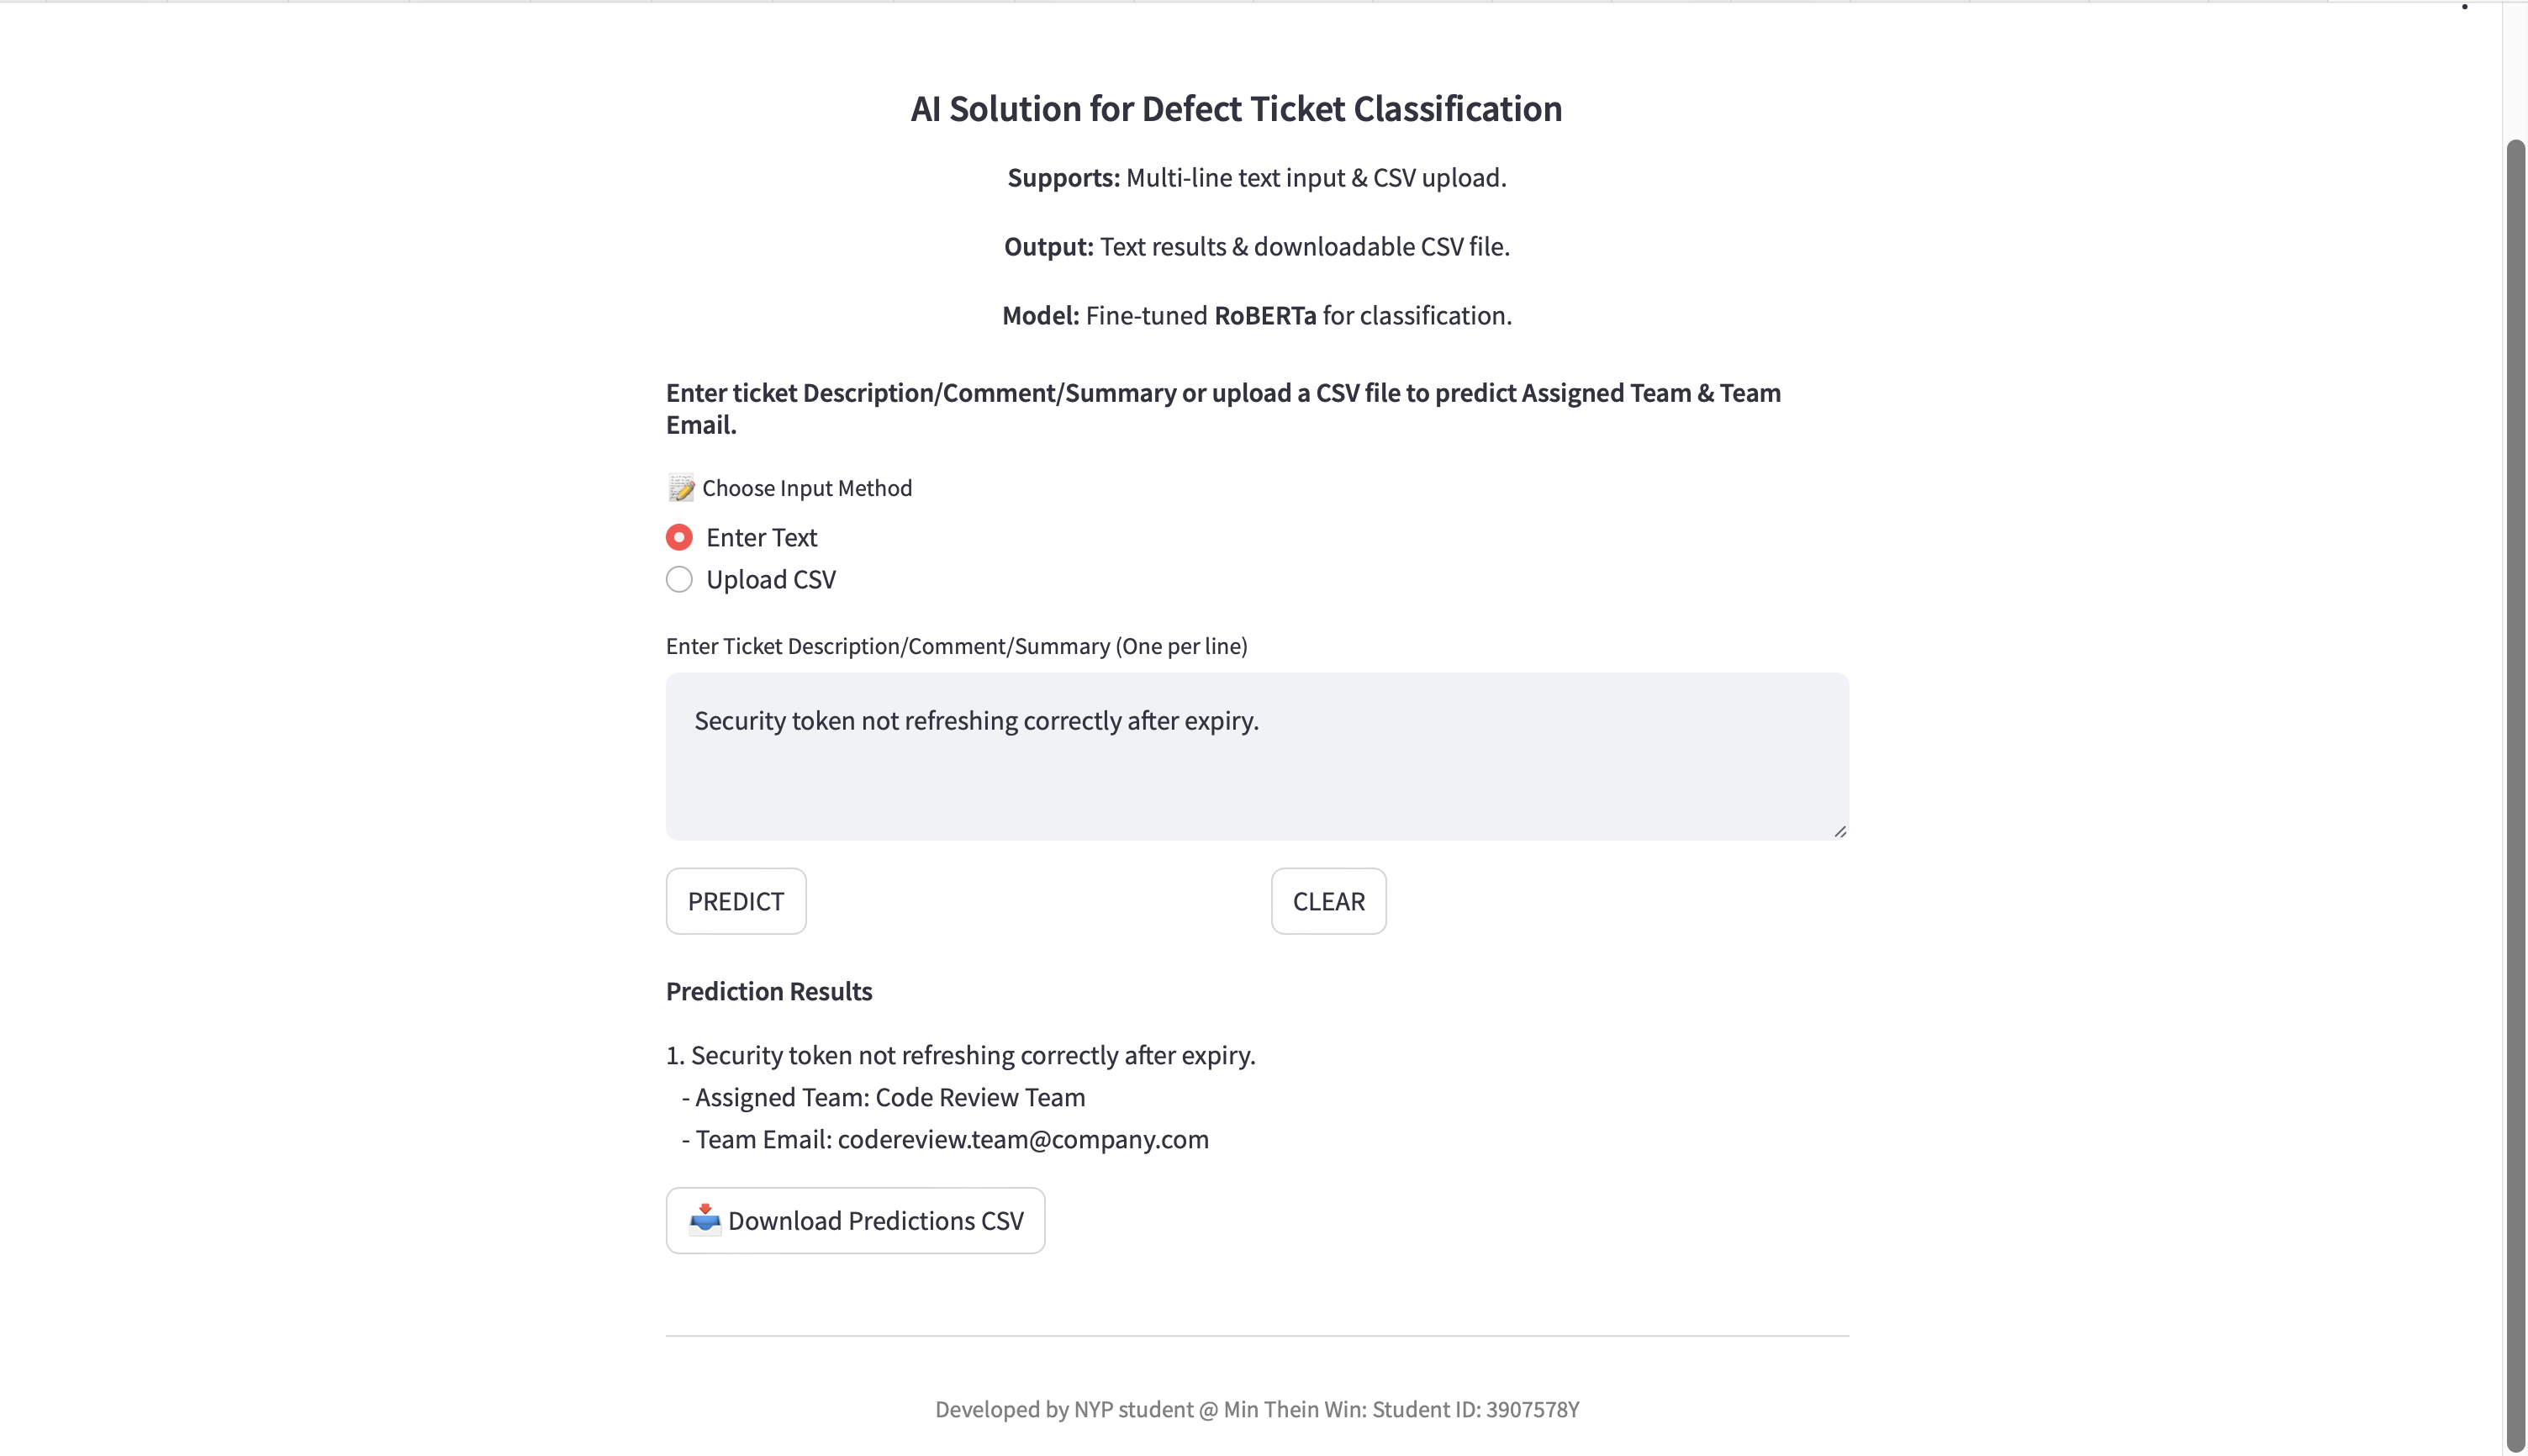

2. Gradio Application

In [ ]:
#Install gradio
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.0/322.0 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
import gradio as gr
import torch
import torch.nn as nn
import pickle
import pandas as pd
from transformers import RobertaTokenizerFast, RobertaModel

# Implement by MinTheinWin@3907578Y
# Load label mappings
with open("label_mappings.pkl", "rb") as f:
    label_mappings = pickle.load(f)

label_to_team = label_mappings.get("label_to_team", {})
label_to_email = label_mappings.get("label_to_email", {})

# Load the tokenizer
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

# Define RoBERTa Model
class RoBertaClassifier(nn.Module):
    def __init__(self, num_teams, num_emails):
        super(RoBertaClassifier, self).__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        self.team_classifier = nn.Linear(self.roberta.config.hidden_size, num_teams)
        self.email_classifier = nn.Linear(self.roberta.config.hidden_size, num_emails)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]

        team_logits = self.team_classifier(cls_output)
        email_logits = self.email_classifier(cls_output)

        return team_logits, email_logits

# Load Model
num_teams = len(label_to_team)
num_emails = len(label_to_email)
model = RoBertaClassifier(num_teams, num_emails)
checkpoint = torch.load("ticket_classification_model.pth", map_location=torch.device("cpu"))
filtered_checkpoint = {k: v for k, v in checkpoint.items() if k in model.state_dict()}
model.load_state_dict(filtered_checkpoint, strict=False)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
model.eval()

# Prediction Function
def predict_tickets(ticket_descriptions):
    predictions = []
    csv_data = []
    for idx, description in enumerate(ticket_descriptions, start=1):
        inputs = tokenizer(description, return_tensors="pt", truncation=True, padding="max_length", max_length=128).to(device)
        with torch.no_grad():
            team_logits, email_logits = model(inputs.input_ids, inputs.attention_mask)
        predicted_team_index = team_logits.argmax(dim=-1).cpu().item()
        predicted_email_index = email_logits.argmax(dim=-1).cpu().item()
        predicted_team = label_to_team.get(predicted_team_index, "Unknown Team")
        predicted_email = label_to_email.get(predicted_email_index, "Unknown Email")
        predictions.append(f"**{idx}. {description}**\n   - **Assigned Team:** {predicted_team}\n   - **Team Email:** {predicted_email}\n")
        csv_data.append([idx, description, predicted_team, predicted_email])

    df = pd.DataFrame(csv_data, columns=["Index", "Description", "Assigned Team", "Team Email"])
    csv_file = "ticket-predictions.csv"
    df.to_csv(csv_file, index=False)
    return "\n".join(predictions), csv_file

# Gradio Functions
def gradio_predict(option, text_input, file_input):
    if option == "Enter Text":
        descriptions = text_input.split("\n")
        descriptions = [desc.strip() for desc in descriptions if desc.strip()]
    elif option == "Upload CSV" and file_input is not None:
        df = pd.read_csv(file_input)
        if "Description" not in df.columns:
            return "⚠️ Error: CSV must contain a 'Description' column.", None
        descriptions = df["Description"].tolist()
    else:
        return "⚠️ Please provide input.", None

    results, csv_file = predict_tickets(descriptions)
    return results, csv_file

def clear_inputs():
    return "Enter Text", "", None, "", None

# Custom CSS for improved UI and fixed input container sizes
custom_css = """
.gradio-container {
    max-width: 1000px !important;
    margin: auto !important;
}
#title {
    text-align: center;
    font-size: 26px !important;
    font-weight: bold;
}
#predict-button, #clear-button, #download-button {
    width: 100% !important;
    height: 55px !important;
    font-size: 18px !important;
}
#results-box {
    height: 350px !important;
    overflow-y: auto !important;
    background: #f9f9f9;
    padding: 15px;
    border-radius: 10px;
    font-size: 16px;
}
/* Reduce vertical padding for the radio component */
#choose_input_method {
    padding-top: 5px !important;
    padding-bottom: 5px !important;
}
/* Force both input components to have the same min-height */
#text_input, #file_input {
    min-height: 200px !important;
    /* Optionally add a consistent border and padding to match styling */
    border: 1px solid #ccc;
    padding: 10px;
}
"""

# Gradio App UI
with gr.Blocks(css=custom_css) as app:
    gr.Markdown(
        """
        # AI Solution for Defect Ticket Classification

        **Supports:** Multi-line text input & CSV upload.
        **Output:** Text results & downloadable CSV file.
        **Model:** Fine-tuned **RoBERTa** for classification.

        Enter ticket Description/Comment/Summary or upload a **CSV file** to predict Assigned Team & Team Email.
        """,
        elem_id="title"
    )

    with gr.Row():
        with gr.Column(scale=1):
            # Radio component with elem_id for CSS targeting
            option = gr.Radio(
                ["Enter Text", "Upload CSV"],
                label="📝 Choose Input Method",
                value="Enter Text",
                elem_id="choose_input_method"
            )

            # Both inputs are given an element id to force consistent dimensions.
            text_input = gr.Textbox(
                label="Enter Ticket Description/Comment/Summary (One per line)",
                visible=True,
                lines=6,
                placeholder="Example:\n - Database performance issue\n - Login fails for admin users...",
                elem_id="text_input"
            )

            file_input = gr.File(
                label="📂 Upload CSV (Optional)",
                type="filepath",
                visible=False,
                elem_id="file_input"
            )

        with gr.Column(scale=1):
            gr.Markdown("## Prediction Results")
            results_output = gr.Markdown(elem_id="results-box", visible=True)
            download_csv = gr.File(label="📥 Download Predictions CSV", interactive=False)

    with gr.Row():
        predict_btn = gr.Button("PREDICT", variant="primary")
        clear_btn = gr.Button("CLEAR", variant="secondary")

    # Toggle the visibility of input components to ensure consistent sizing
    def toggle_input(selected_option):
        if selected_option == "Enter Text":
            return gr.update(visible=True), gr.update(visible=False)
        else:
            return gr.update(visible=False), gr.update(visible=True)

    option.change(fn=toggle_input, inputs=[option], outputs=[text_input, file_input])
    predict_btn.click(fn=gradio_predict, inputs=[option, text_input, file_input], outputs=[results_output, download_csv])
    clear_btn.click(fn=clear_inputs, inputs=[], outputs=[option, text_input, file_input, results_output, download_csv])

    # Footer view
    gr.Markdown("---")
    gr.HTML(
        """
        <div style="text-align: center; color: gray; padding-top: 10px;">
            <p>Developed by NYP student @ Min Thein Win: Student ID: 3907578Y</p>
        </div>
        """
    )

# Launch App
app.launch(share=True)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-42-06a83bb9cfd8>:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recom

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b60189256227bde452.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


2.1 Gradio Application Code

Gradio application User Interface Design.

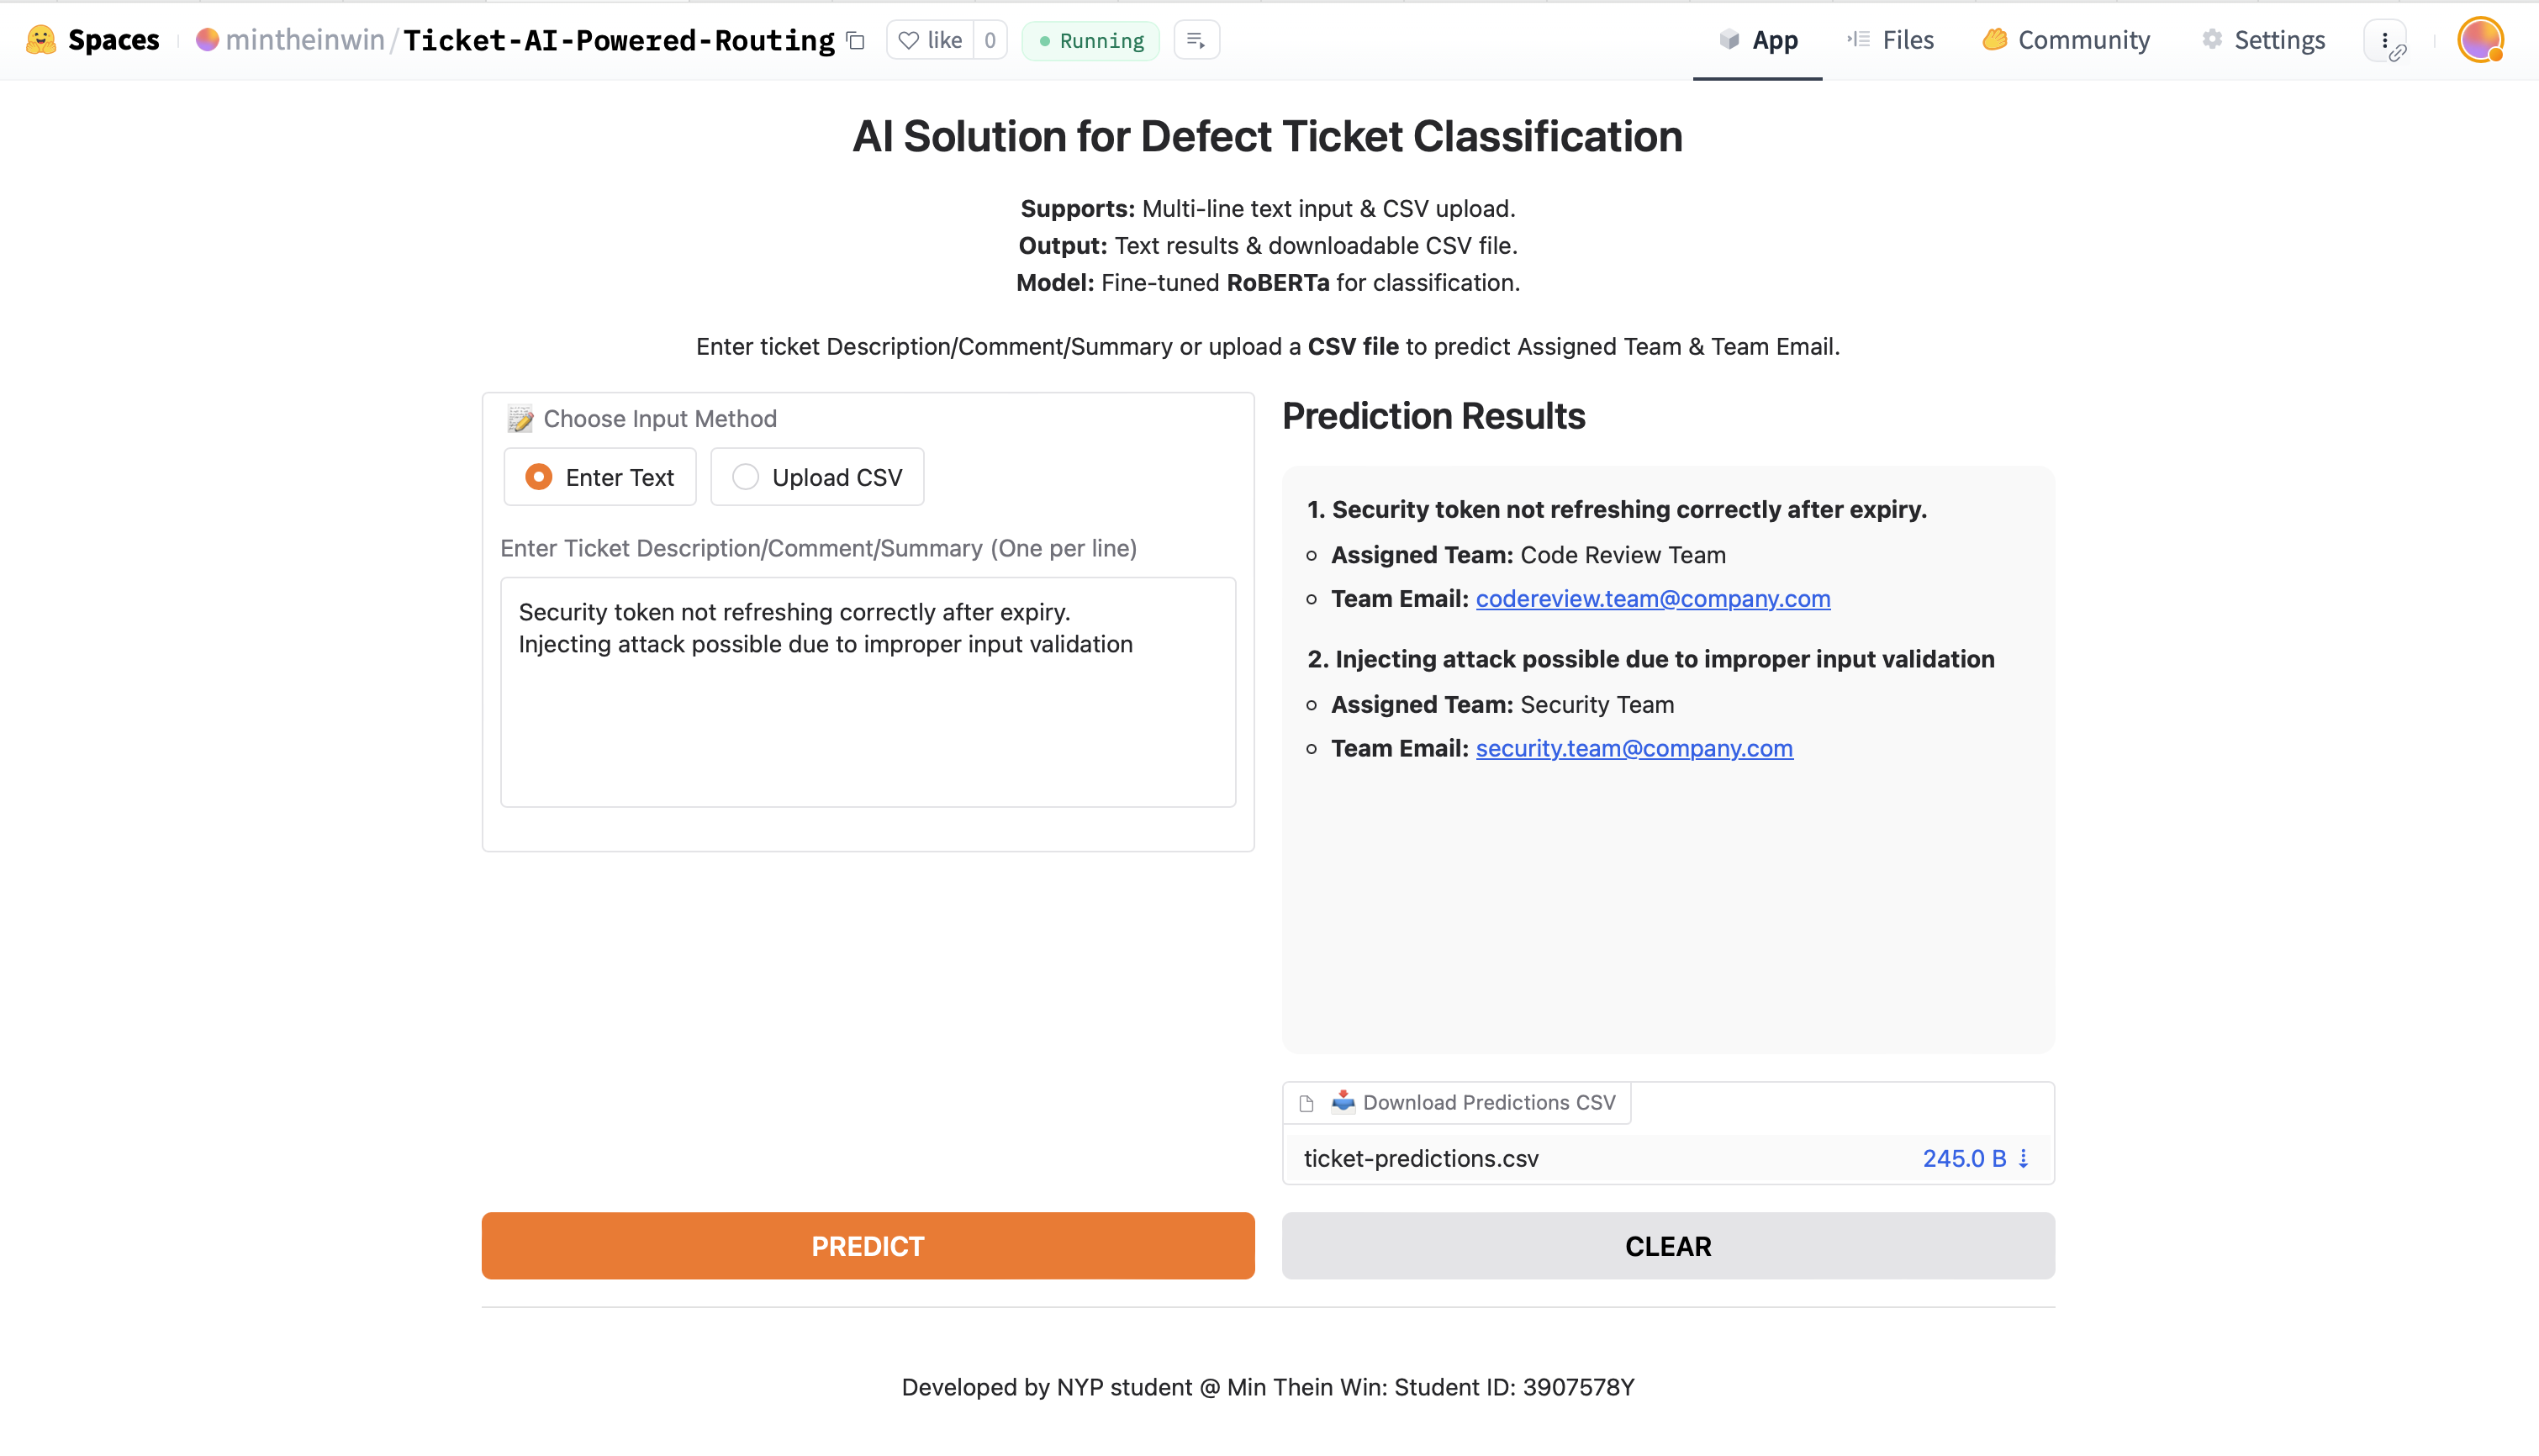